In [62]:
const PROJECT_ROOT = joinpath(homedir(), "work", "Deborah.jl")
function localpath(relpath::AbstractString)
    return joinpath(PROJECT_ROOT, relpath)
end
# Base.invokelatest(include, localpath("src/Deborah.jl"))
# import .Deborah
using Revise
import Deborah; flush(stdout); flush(stderr)
import TOML
import Statistics

ns=8
nt=4
b="1.60"
kappa="13580"

# ns=12
# nt=4
# b="1.66"
# kappa="13275"

ensemble="L$(ns)T$(nt)b$(b)k$(kappa)"

work = "nf4_clover_wilson_finiteT"

observable="plaq.dat"
# observable="rect.dat"
# observable="trdinv4.dat"

raw_path = localpath(joinpath(work, ensemble))

jobid = nothing

X_df = Deborah.Sarah.DataLoader.load_data_file(raw_path, observable, jobid)

N_cnf = size(X_df, 1)
N_src = 1
read_column_X = 1

bin_size = 1

X_info = Deborah.Sarah.XYInfoGenerator.gen_X_info(X_df, N_cnf, N_src, read_column_X)

X_info_ORG = [Statistics.mean(X_info[read_column_X, iconf, :]) for iconf in 1:N_cnf]

conf_idx_vec = 1:N_cnf
conf_idx = collect(conf_idx_vec)

Deborah.Rebekah.PyPlotLaTeX.set_pyplot_latex_style()

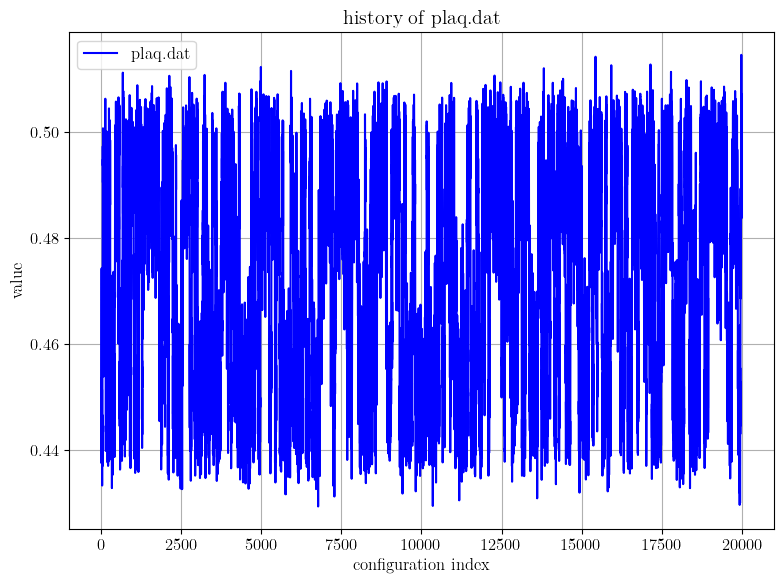

In [63]:
Deborah.Rahab.ObservableHistory.observable_history(conf_idx, X_info_ORG, observable)

Divisors of 1000: [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]


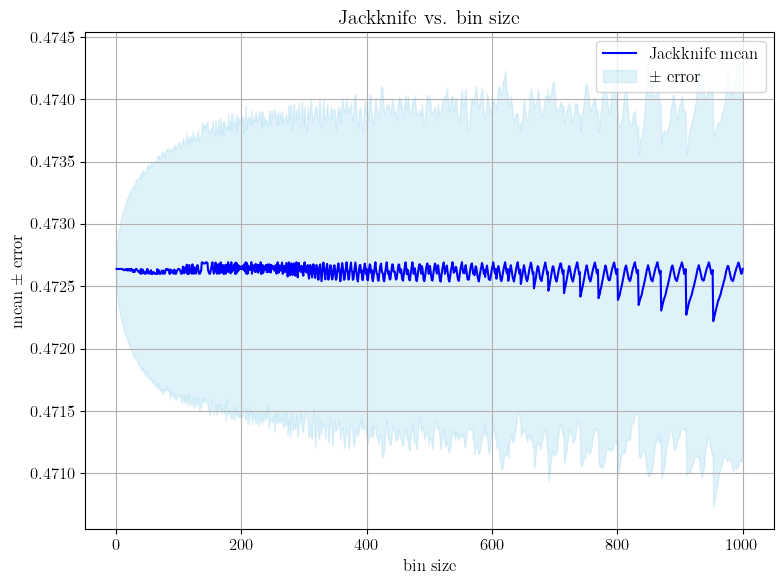

([0.472639347999606, 0.47263934799960605, 0.4726380915088976, 0.4726393479996059, 0.472639347999606, 0.4726380915088976, 0.4726387846403916, 0.472639347999606, 0.47263809150889763, 0.472639347999606  …  0.472654335754925, 0.47267114632637436, 0.472690359794017, 0.47268363809924996, 0.4726586757277146, 0.472638007855496, 0.47261283008065913, 0.47259999330998426, 0.47261522651211096, 0.4726393479996062], [0.0001483832043140514, 0.00020693544857345328, 0.0002512606516404142, 0.0002880865211333691, 0.00031990883336887157, 0.00034853387998862764, 0.0003740846760657658, 0.00039819741475746994, 0.0004200512540352513, 0.0004400225978858217  …  0.00161478048813885, 0.0016255709898548999, 0.0016314771408643778, 0.0016036044602678033, 0.0015594111507980957, 0.001527376990156664, 0.0015167386849781366, 0.001512761624946255, 0.0014927065382877558, 0.001465842110510848])

In [64]:
# ---- compute divisors of tot_bin ----
tot_bin = 1000

# Sweep block size
max_bin = min(tot_bin, N_cnf)
bin_sizes = collect(1:max_bin)

means, errs = Deborah.Rahab.BlockBinScan.jackknife_bin_scan(
    X_info_ORG, 
    bin_sizes,
    tot_bin
)

In [65]:
win = 40  # window of block size; e.g., 10 means [1..10], [11..20], ... 

40

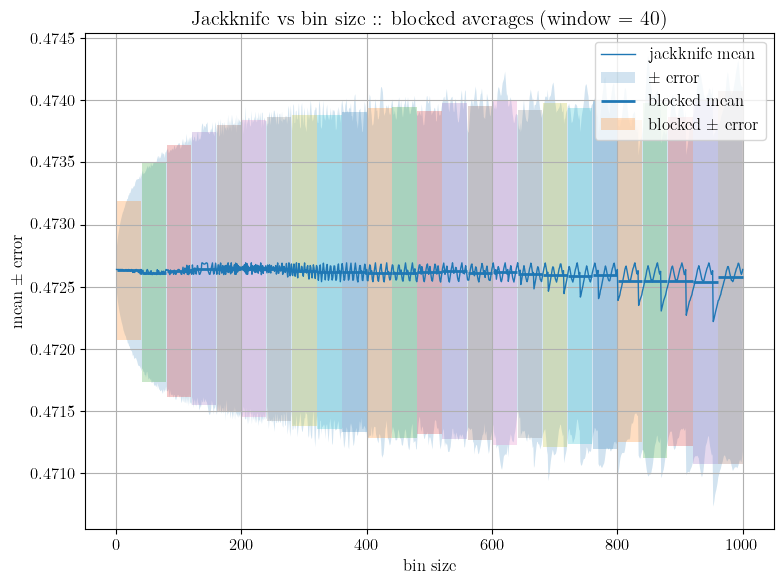

In [66]:
Deborah.Rahab.BlockBinScan.jackknife_bin_scan_blocked_average(
    bin_sizes,
    means,
    errs,
    win;
    include_tail=false
)

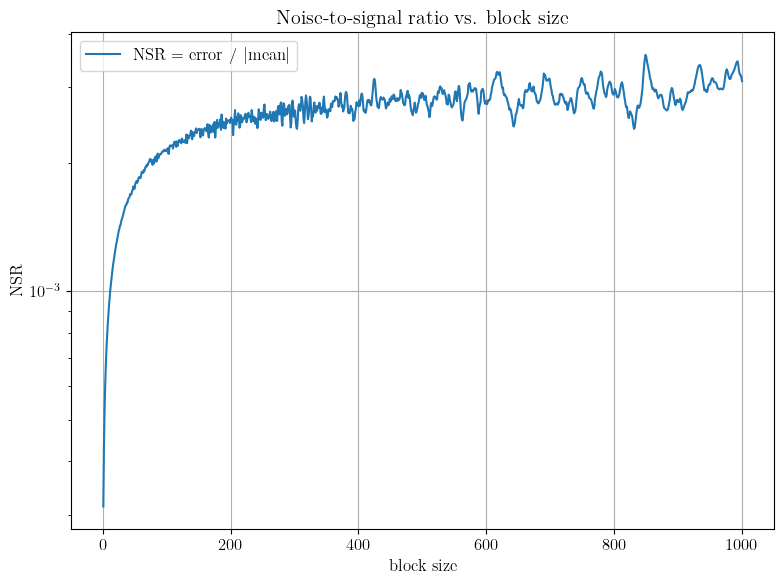

In [67]:
Deborah.Rahab.BlockBinScan.nsr_block_scan(
    bin_sizes,
    means,
    errs;
    logscale=true
)


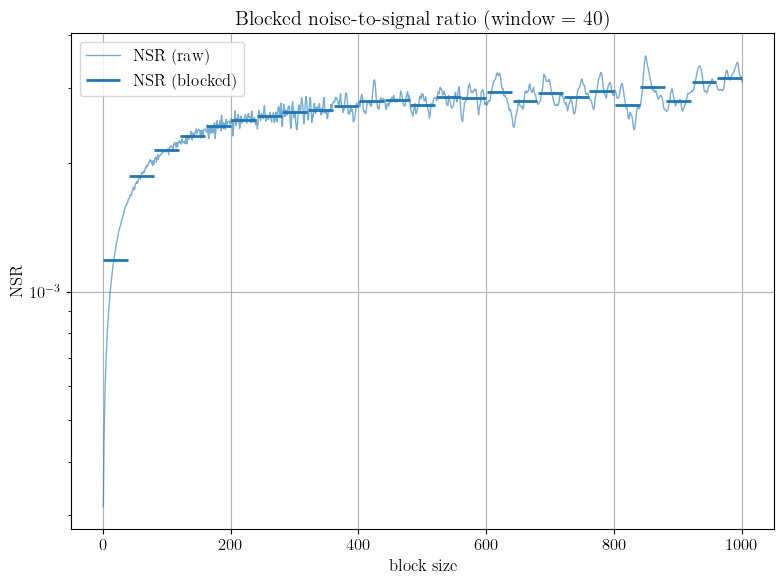

In [68]:
Deborah.Rahab.BlockBinScan.nsr_block_scan_blocked_average(
    bin_sizes,
    means,
    errs,
    win;
    include_tail=false,
    logscale=true
)

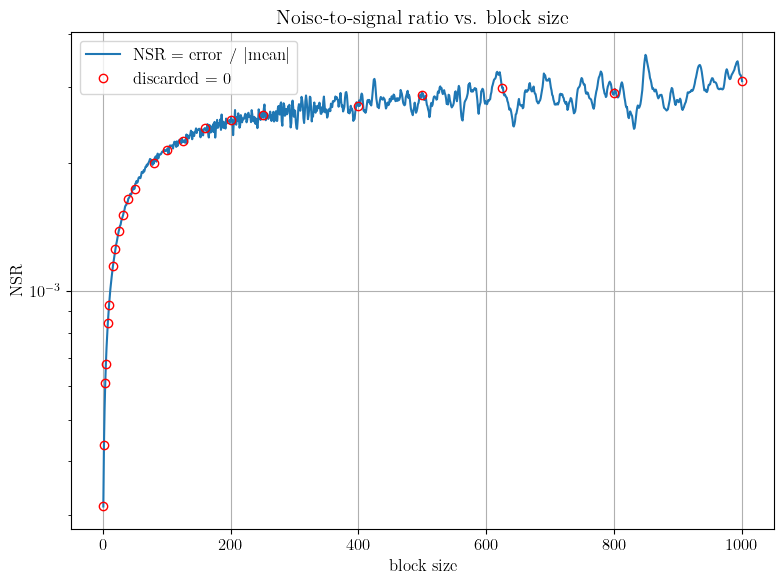

([1, 2, 4, 5, 8, 10, 16, 20, 25, 32  …  100, 125, 160, 200, 250, 400, 500, 625, 800, 1000], [0.0003139459398420105, 0.00043782949821948757, 0.0006095271634760492, 0.0006768561160276868, 0.0008424973850416743, 0.0009309901931529165, 0.0011454246921807313, 0.0012578751998725338, 0.0013821178645541281, 0.001508763380707478  …  0.0021452333243414524, 0.0022495359320572794, 0.002409561006474788, 0.0025096178003278023, 0.0025782658884857157, 0.0027103289788157265, 0.0028776740984551557, 0.002985243012542424, 0.0029053592305806086, 0.0031013966922450757], [0, 0, 2, 0, 0, 2, 1, 0, 2, 0  …  180, 160, 140, 120, 100, 80, 60, 40, 20, 0])

In [69]:
Deborah.Rahab.BlockBinScan.nsr_block_scan_with_discarded_zero(
    X_info_ORG,
    tot_bin,
    means,
    errs;
    logscale=true
)

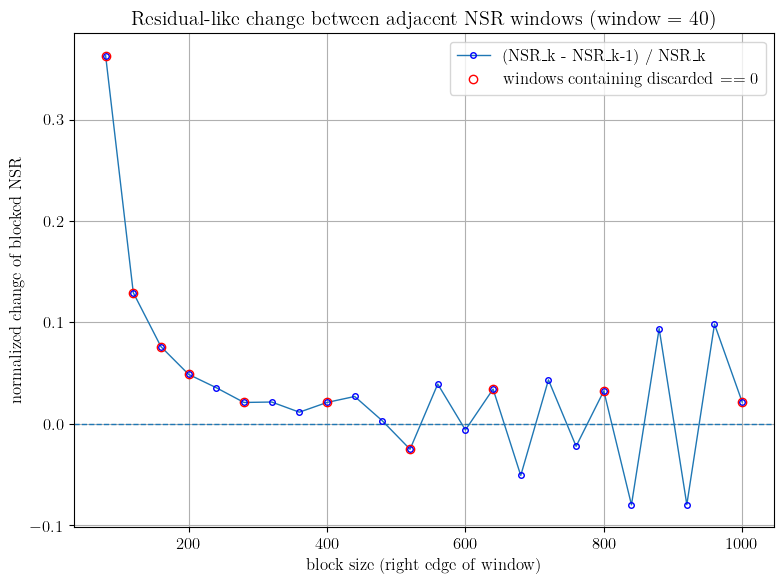

block sizes with discarded == 0: [1, 2, 4, 5, 8, 10, 16, 20, 25, 32, 40, 50, 80, 100, 125, 160, 200, 250, 400, 500, 625, 800, 1000]
window indices (k) that contain any discarded == 0: [2, 3, 4, 5, 7, 10, 13, 16, 20, 25]
x(right-edge) for those windows: [80, 120, 160, 200, 280, 400, 520, 640, 800, 1000]


([80, 120, 160, 200, 280, 400, 520, 640, 800, 1000], [0.36311962922497054, 0.12935338006462122, 0.07609254506778727, 0.04876993563767516, 0.021077221789736738, 0.02111230958593249, -0.02507891838435309, 0.03428698631396422, 0.03244974389860115, 0.02153184481814382], [0, 0, 2, 0, 0, 2, 1, 0, 2, 0  …  180, 160, 140, 120, 100, 80, 60, 40, 20, 0])

In [70]:
xs, ys, discarded = Deborah.Rahab.BlockBinScan.nsr_block_scan_blocked_relchange(
    X_info_ORG,
    tot_bin,
    means,
    errs,
    win;
    logscale=false
)

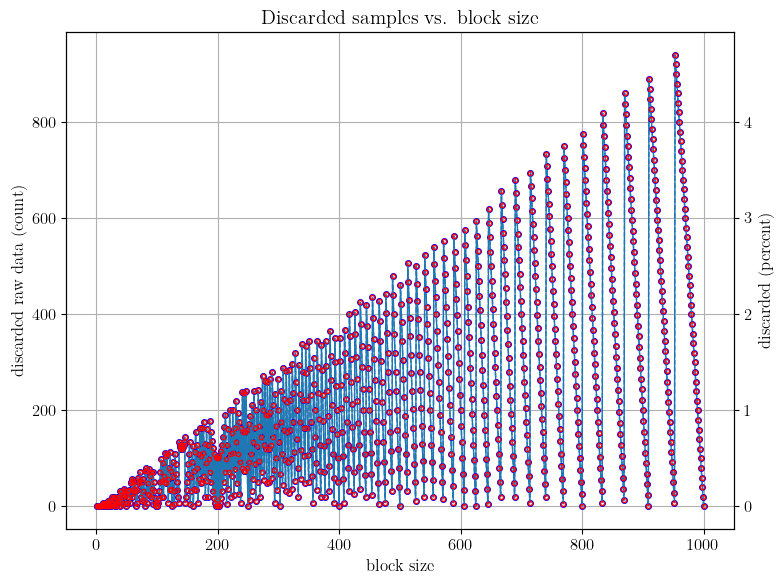

1000-element Vector{Int64}:
   0
   0
   2
   0
   0
   2
   1
   0
   2
   0
   ⋮
 160
 140
 120
 100
  80
  60
  40
  20
   0

In [ ]:
Deborah.Rahab.BlockBinScan.plot_discarded_vs_blocks(
    X_info_ORG,
    tot_bin;
    style="both"
)